# Extracción de perfiles del International Multi-Tokamak Confinement Profile Database

In [1]:
import MDSplus
import numpy as np
import matplotlib.pyplot as plt

In [26]:
# Conexión a la base de Datos
conn = MDSplus.Connection('tokamak-profiledb.ccfe.ac.uk')
conn.openTree('pr08_rtp', 97052261)

In [27]:
amin = conn.get(r'\top.zerod:amin').data()
#rmag = conn.get(r'\top.zerod:rmag').data()
#zmag = conn.get(r'\top.zerod:zmag').data()
rgeo = conn.get(r'\top.zerod:rgeo').data()

In [38]:
# Obtención de los perfiles T y n como F(r,t)
Te = conn.get(r'\top.twod:te').data()
ne = conn.get(r'\top.twod:ne').data()
print(f"{Te.max() * 1.0e3}") 

701.77


In [29]:
t = conn.get(r'dim_of(\top.twod:te,1)').data()
rho = conn.get(r'dim_of(\top.twod:te,0)').data() 

In [30]:
t

array([0.3])

In [31]:
Te_unit = conn.get(r'units_of(\top.twod:te)').data()
ne_unit = conn.get(r'units_of(\top.twod:ne)').data()
t_unit  = conn.get(r'units_of(dim_of(\top.twod:te,1))').data()
r_unit  = conn.get(r'units_of(dim_of(\top.twod:te,0))').data()

In [32]:
ne_unit

'm-3'

In [33]:
That = np.copy((Te - Te.min()) / (Te.max() - Te.min()))
nhat = np.copy((ne - ne.min()) / (ne.max() - ne.min()))

In [10]:
#assert Te.shape == (len(t), len(r)), f"Unexpected Te shape: {Te.shape}, t={len(t)}, r={len(r)}"
#assert ne.shape == (len(t), len(r)), f"Unexpected Te shape: {ne.shape}, t={len(t)}, r={len(r)}"

In [34]:
t0 = 9.6
itime = np.argmin(np.abs(t - t0))

In [35]:
#Te_r = Te[itime, :]
#ne_r = ne[itime, :]

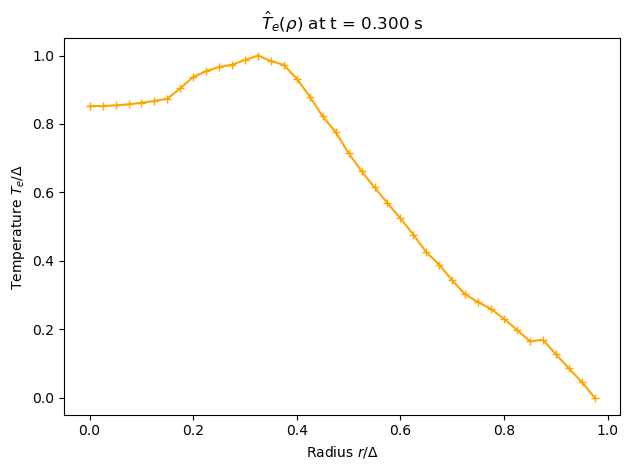

In [39]:
plt.figure()
plt.plot(rho, That, marker='+', linestyle='-', color='orange')
plt.xlabel(r"Radius $r / \Delta$")
plt.ylabel("Temperature $T_e / \Delta$")
plt.title(r"$\hat{T}_e(\rho)$ at t = " + f"{t[0]:.3f} {t_unit}")
plt.tight_layout()
plt.show()

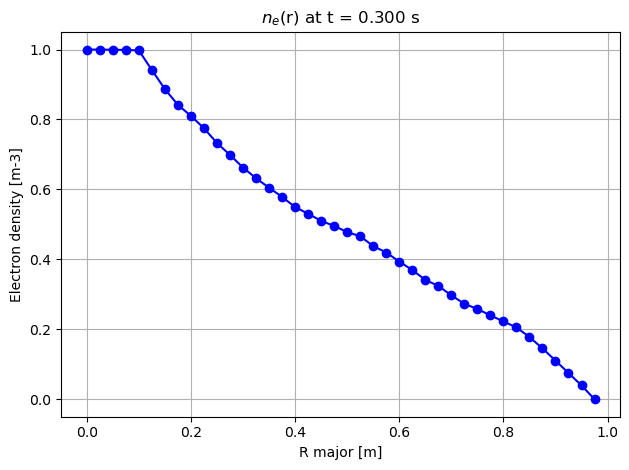

In [37]:
plt.figure()
plt.plot(rho, nhat, marker='o', linestyle='-', color='blue')
plt.xlabel(r"R major [m]")
plt.ylabel(f"Electron density [{ne_unit}]")
plt.title(rf"$n_e$(r) at t = {t[itime]:.3f} {t_unit}")
plt.grid(True)
plt.tight_layout()
plt.show()